# InSAR Results Visualization - Fixed Version

This notebook visualizes the ISCE2 interferogram results from Tokyo, Japan

**Date pair:**
- Reference: 2021-01-31
- Secondary: 2021-02-12
- Temporal baseline: 12 days

## ⚠️ IMPORTANT: What This Notebook Shows

✅ **AVAILABLE (visualized here):**
- **Wrapped interferometric phase** (-π to π radians)
- **Amplitude** (backscatter intensity) - with log scaling to handle huge dynamic range
- **Coherence** (quality metric) - normalized from ISCE2's raw values
- **LOS geometry angles** (incidence & heading) - converted to E/N/U unit vectors

❌ **NOT AVAILABLE (unwrapping was disabled):**
- Unwrapped phase
- Line-of-sight displacement
- Actual deformation measurements

### Data Fixes Applied:
1. **Amplitude**: Uses log₁₀ scale (raw values: 1.3 to 1,519,865)
2. **Coherence**: Uses correct file `phsig.cor` (0-1 scale), not `topophase.cor`
3. **LOS geometry**: Only 2 bands exist (incidence, heading), computed E/N/U vectors

**To get displacement:** Enable unwrapping in `topsApp.xml` by uncommenting:
```xml
<property name="do unwrap">True</property>
<property name="unwrapper name">snaphu_mcf</property>
```

In [12]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
from pathlib import Path

# Enable GDAL exceptions (suppress warning)
gdal.UseExceptions()

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")
print(f"GDAL version: {gdal.__version__}")

✅ Libraries imported successfully!
GDAL version: 3.10.3


In [13]:
# Define paths to the InSAR products
merged_dir = Path('/home/ubuntu/work/isce2-playbook/merged')

# List available files
print("Available InSAR products:")
for file in sorted(merged_dir.glob('*.vrt')):
    print(f"  - {file.name}")

Available InSAR products:
  - dem.crop.vrt
  - filt_topophase.flat.geo.vrt
  - filt_topophase.flat.vrt
  - lat.rdr.full.vrt
  - lon.rdr.full.vrt
  - los.rdr.full.vrt
  - los.rdr.geo.vrt
  - los.rdr.vrt
  - phsig.cor.geo.vrt
  - phsig.cor.vrt
  - reference.slc.full.vrt
  - secondary.slc.full.vrt
  - topophase.cor.full.vrt
  - topophase.cor.geo.vrt
  - topophase.cor.vrt
  - topophase.flat.full.vrt
  - topophase.flat.geo.vrt
  - topophase.flat.vrt
  - z.rdr.full.vrt


## 1. Load and Visualize Wrapped Interferometric Phase (Radar Coordinates)

**Note:** This is WRAPPED phase (cycles between -π and π). Each full cycle (fringe) represents ~2.8 cm of line-of-sight displacement for Sentinel-1.

### Amplitude Formula:
The interferogram is stored as a **complex number** (real + imaginary parts):
- **Amplitude** = |interferogram| = √(real² + imaginary²)  
- **Phase** = arctan(imaginary / real)

The amplitude represents the **strength of the radar return signal** (backscatter intensity), NOT displacement.

In [14]:
# Load the filtered interferogram
ifg_file = merged_dir / 'filt_topophase.flat.vrt'

ds = gdal.Open(str(ifg_file))
print(f"Dataset size: {ds.RasterXSize} x {ds.RasterYSize}")
print(f"Number of bands: {ds.RasterCount}")
data_type = ds.GetRasterBand(1).DataType
print(f"Data type: {gdal.GetDataTypeName(data_type)}")
print("\n📌 CFloat32 = Complex float (real + imaginary stored in one band)")

# Read complex data directly (CFloat32 stores both real and imaginary in one band)
ifg_complex = ds.GetRasterBand(1).ReadAsArray()

# Mask zero values
ifg_complex[ifg_complex == 0] = np.nan

# Calculate amplitude and WRAPPED phase
amplitude = np.abs(ifg_complex)
phase_wrapped = np.angle(ifg_complex)  # THIS IS WRAPPED PHASE (-π to π)

print(f"\n⚠️  This is WRAPPED PHASE (not unwrapped!)")
print(f"   Phase unwrapping was DISABLED in topsApp.xml")
print(f"\nAmplitude range: {np.nanmin(amplitude):.2f} to {np.nanmax(amplitude):.2f}")
print(f"Wrapped phase range: {np.nanmin(phase_wrapped):.2f} to {np.nanmax(phase_wrapped):.2f} radians")

ds = None  # Close dataset

Dataset size: 1122 x 1938
Number of bands: 1
Data type: CFloat32

📌 CFloat32 = Complex float (real + imaginary stored in one band)

⚠️  This is WRAPPED PHASE (not unwrapped!)
   Phase unwrapping was DISABLED in topsApp.xml

Amplitude range: 1.31 to 1519865.00
Wrapped phase range: -3.14 to 3.14 radians


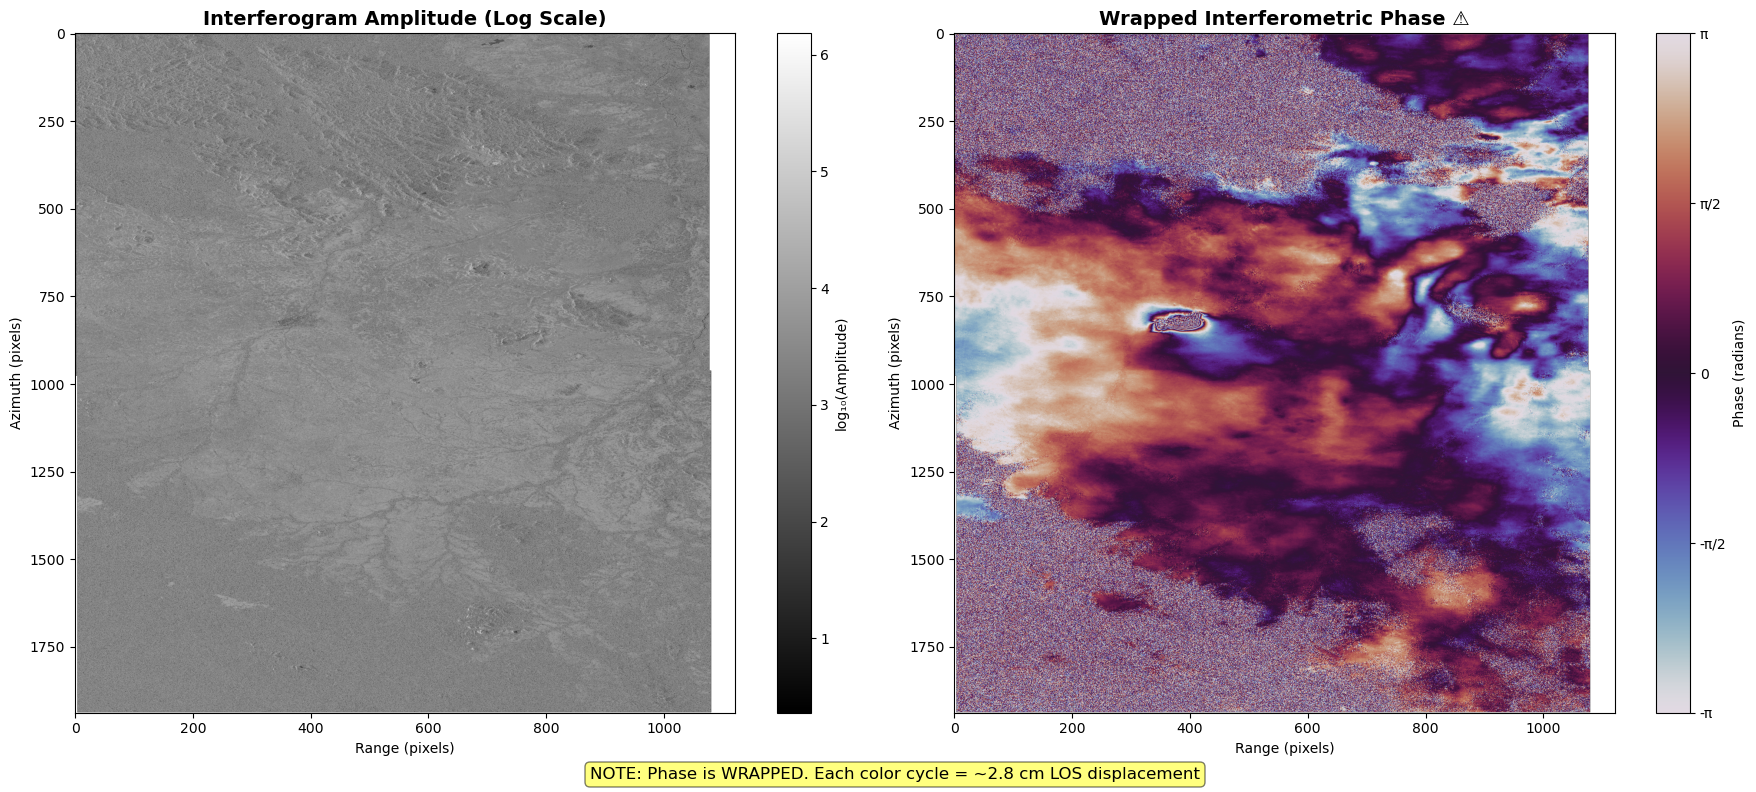

✅ Interferogram plot saved as 'interferogram_radar_coords.png'


In [15]:
# Plot interferogram amplitude and wrapped phase
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Amplitude plot with log scaling (huge dynamic range: 1.3 to 1.5M)
# Formula: amplitude = |complex_interferogram| = sqrt(real² + imaginary²)
amplitude_log = np.log10(amplitude + 1)  # Add 1 to avoid log(0)
im1 = axes[0].imshow(amplitude_log, cmap='gray', aspect='auto')
axes[0].set_title('Interferogram Amplitude (Log Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Range (pixels)')
axes[0].set_ylabel('Azimuth (pixels)')
plt.colorbar(im1, ax=axes[0], label='log₁₀(Amplitude)')

# Wrapped Phase plot
im2 = axes[1].imshow(phase_wrapped, cmap='twilight', vmin=-np.pi, vmax=np.pi, aspect='auto')
axes[1].set_title('Wrapped Interferometric Phase ⚠️', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Range (pixels)')
axes[1].set_ylabel('Azimuth (pixels)')
cbar = plt.colorbar(im2, ax=axes[1], label='Phase (radians)')
cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])

fig.text(0.5, 0.02, 'NOTE: Phase is WRAPPED. Each color cycle = ~2.8 cm LOS displacement', 
         ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('interferogram_radar_coords.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Interferogram plot saved as 'interferogram_radar_coords.png'")

## 2. Load and Visualize Coherence Map

Coherence ranges from 0 (no correlation) to 1 (perfect correlation). High coherence areas are more reliable for phase interpretation.

In [27]:
# Load coherence/correlation
# IMPORTANT: Use phsig.cor (actual coherence 0-1), NOT topophase.cor (raw correlation)
cor_file = merged_dir / 'phsig.cor.vrt'

ds = gdal.Open(str(cor_file))
coherence = ds.GetRasterBand(1).ReadAsArray()
coherence[coherence == 0] = np.nan

print(f"Coherence file: {cor_file.name}")
print(f"Coherence range: {np.nanmin(coherence):.3f} to {np.nanmax(coherence):.3f}")
print(f"Mean coherence: {np.nanmean(coherence):.3f}")
print(f"\n✅ This is the correct coherence (0-1 scale, no normalization needed)")
print(f"\nQuality Assessment:")
print(f"  High coherence (>0.7): {(np.sum(coherence > 0.7) / np.sum(~np.isnan(coherence)) * 100):.1f}%")
print(f"  Good coherence (0.5-0.7): {(np.sum((coherence > 0.5) & (coherence <= 0.7)) / np.sum(~np.isnan(coherence)) * 100):.1f}%")
print(f"  Low coherence (<0.5): {(np.sum(coherence < 0.5) / np.sum(~np.isnan(coherence)) * 100):.1f}%")

ds = None

Coherence file: phsig.cor.vrt
Coherence range: 0.161 to 1.000
Mean coherence: 0.708

✅ This is the correct coherence (0-1 scale, no normalization needed)

Quality Assessment:
  High coherence (>0.7): 59.4%
  Good coherence (0.5-0.7): 3.6%
  Low coherence (<0.5): 37.1%


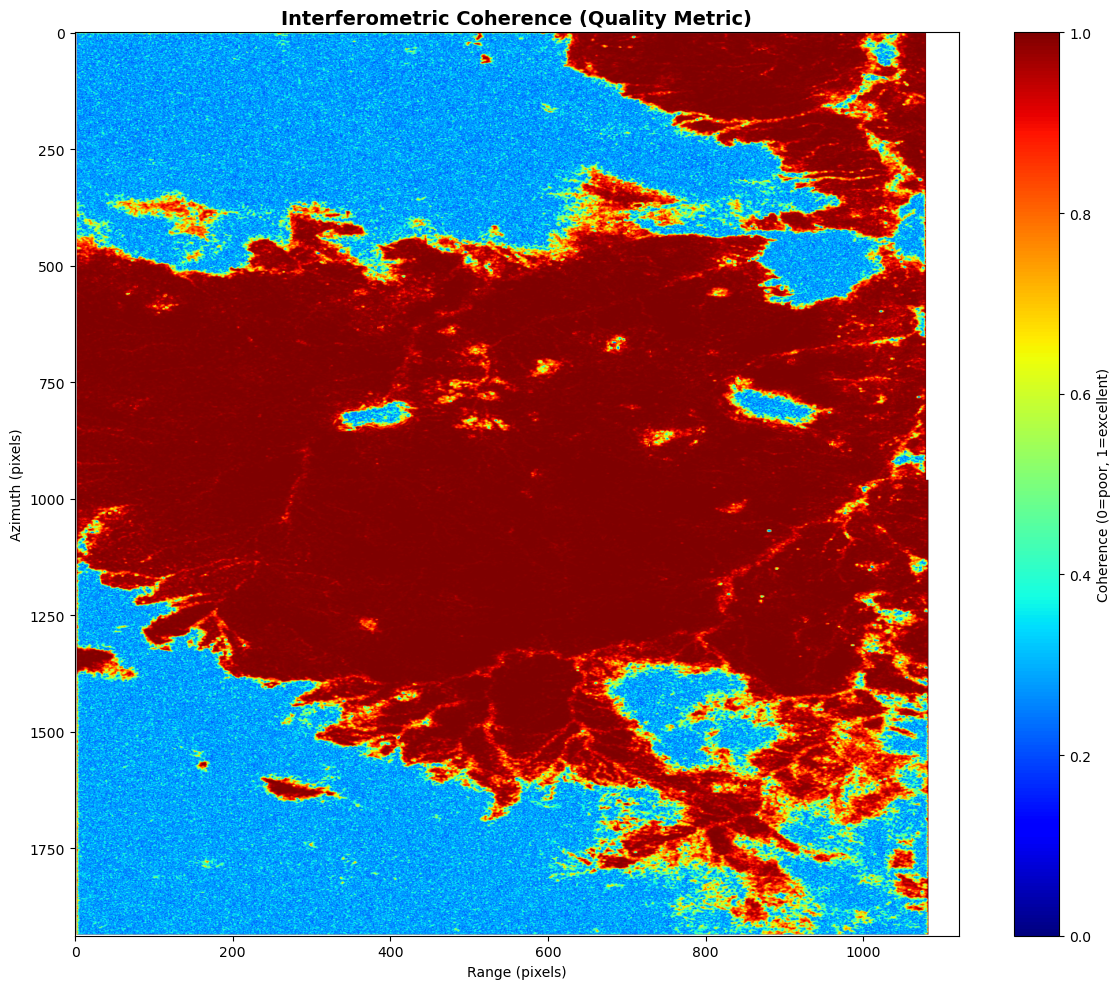

✅ Coherence map saved as 'coherence_map.png'


In [28]:
# Plot coherence
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

im = ax.imshow(coherence, cmap='jet', vmin=0, vmax=1, aspect='auto')
ax.set_title('Interferometric Coherence (Quality Metric)', fontsize=14, fontweight='bold')
ax.set_xlabel('Range (pixels)')
ax.set_ylabel('Azimuth (pixels)')
cbar = plt.colorbar(im, ax=ax, label='Coherence (0=poor, 1=excellent)')

plt.tight_layout()
plt.savefig('coherence_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Coherence map saved as 'coherence_map.png'")

## 3. Load and Visualize Geocoded Wrapped Phase

The geocoded products have geographic coordinates (lat/lon) for easy overlay with maps.

In [20]:
# Load geocoded filtered interferogram
ifg_geo_file = merged_dir / 'filt_topophase.flat.geo.vrt'

ds = gdal.Open(str(ifg_geo_file))

# Get geotransform for coordinates
geotransform = ds.GetGeoTransform()
print(f"Geotransform: {geotransform}")

# Extract coordinate info
lon_origin = geotransform[0]
lat_origin = geotransform[3]
pixel_width = geotransform[1]
pixel_height = geotransform[5]

# Calculate extent
cols = ds.RasterXSize
rows = ds.RasterYSize
lon_max = lon_origin + cols * pixel_width
lat_min = lat_origin + rows * pixel_height

extent = [lon_origin, lon_max, lat_min, lat_origin]

print(f"\nGeographic extent:")
print(f"  Longitude: {lon_origin:.4f}° to {lon_max:.4f}°")
print(f"  Latitude: {lat_min:.4f}° to {lat_origin:.4f}°")

# Read complex data (CFloat32 - one band)
ifg_geo_complex = ds.GetRasterBand(1).ReadAsArray()
ifg_geo_complex[ifg_geo_complex == 0] = np.nan

amplitude_geo = np.abs(ifg_geo_complex)
phase_geo_wrapped = np.angle(ifg_geo_complex)

ds = None

Geotransform: (-60.32944444444445, 0.0002777777777777778, 0.0, 3.5458333333333334, 0.0, -0.0002777777777777778)

Geographic extent:
  Longitude: -60.3294° to -59.0819°
  Latitude: 1.6694° to 3.5458°


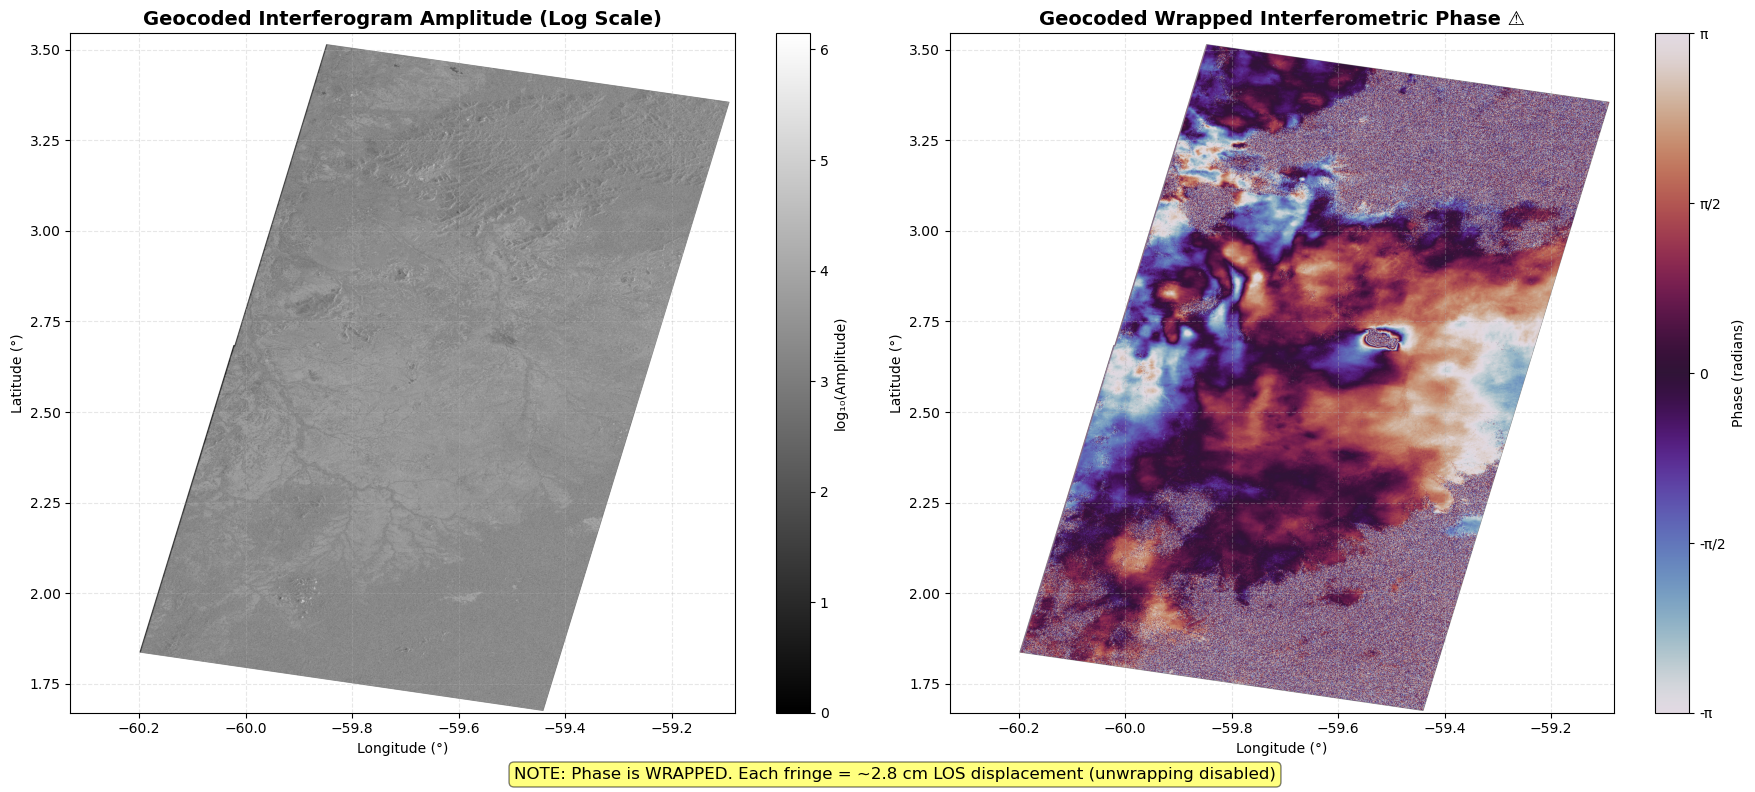

✅ Geocoded interferogram plot saved as 'interferogram_geocoded.png'


In [21]:
# Plot geocoded interferogram
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Amplitude plot with log scaling
amplitude_geo_log = np.log10(amplitude_geo + 1)
im1 = axes[0].imshow(amplitude_geo_log, cmap='gray', extent=extent, aspect='auto')
axes[0].set_title('Geocoded Interferogram Amplitude (Log Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude (°)')
axes[0].set_ylabel('Latitude (°)')
plt.colorbar(im1, ax=axes[0], label='log₁₀(Amplitude)')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Wrapped Phase plot
im2 = axes[1].imshow(phase_geo_wrapped, cmap='twilight', vmin=-np.pi, vmax=np.pi, 
                     extent=extent, aspect='auto')
axes[1].set_title('Geocoded Wrapped Interferometric Phase ⚠️', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude (°)')
axes[1].set_ylabel('Latitude (°)')
cbar = plt.colorbar(im2, ax=axes[1], label='Phase (radians)')
cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[1].grid(True, alpha=0.3, linestyle='--')

fig.text(0.5, 0.02, 'NOTE: Phase is WRAPPED. Each fringe = ~2.8 cm LOS displacement (unwrapping disabled)', 
         ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('interferogram_geocoded.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Geocoded interferogram plot saved as 'interferogram_geocoded.png'")

## 4. Line-of-Sight (LOS) Geometry Angles

**Important:** These are NOT displacement values! These are the satellite viewing angles (incidence and heading/azimuth).

In [23]:
# Load LOS geometry file  
los_file = merged_dir / 'los.rdr.vrt'

ds = gdal.Open(str(los_file))
print(f"LOS file has {ds.RasterCount} bands")
print("  Band 1: Incidence angle (degrees)")
print("  Band 2: Heading/Azimuth angle (degrees)")
print("\nNote: ISCE2 los.rdr stores angles directly, not unit vectors")

# Read LOS angles (in degrees)
incidence_angle = ds.GetRasterBand(1).ReadAsArray()
heading_angle = ds.GetRasterBand(2).ReadAsArray()

# Mask zeros
incidence_angle[incidence_angle == 0] = np.nan
heading_angle[heading_angle == 0] = np.nan

# Calculate unit vector components from angles
# Incidence: angle from vertical (0° = straight down, 90° = horizontal)
# Heading: azimuth direction (clockwise from North)
los_up = np.cos(np.deg2rad(incidence_angle))
los_east = np.sin(np.deg2rad(incidence_angle)) * np.sin(np.deg2rad(heading_angle + 90))  # +90 for Sentinel-1 right-looking
los_north = np.sin(np.deg2rad(incidence_angle)) * np.cos(np.deg2rad(heading_angle + 90))

print(f"\nLOS Geometry Statistics:")
print(f"  Incidence angle: {np.nanmean(incidence_angle):.2f}° (range: {np.nanmin(incidence_angle):.2f}° to {np.nanmax(incidence_angle):.2f}°)")
print(f"  Heading angle: {np.nanmean(heading_angle):.2f}° (range: {np.nanmin(heading_angle):.2f}° to {np.nanmax(heading_angle):.2f}°)")
print(f"  Computed unit vector magnitudes: {np.nanmean(np.sqrt(los_east**2 + los_north**2 + los_up**2)):.3f} (should be ~1.0)")

ds = None


LOS file has 2 bands
  Band 1: Incidence angle (degrees)
  Band 2: Heading/Azimuth angle (degrees)

Note: ISCE2 los.rdr stores angles directly, not unit vectors

LOS Geometry Statistics:
  Incidence angle: 33.90° (range: 30.77° to 36.76°)
  Heading angle: -101.80° (range: -101.85° to -101.74°)
  Computed unit vector magnitudes: 1.000 (should be ~1.0)


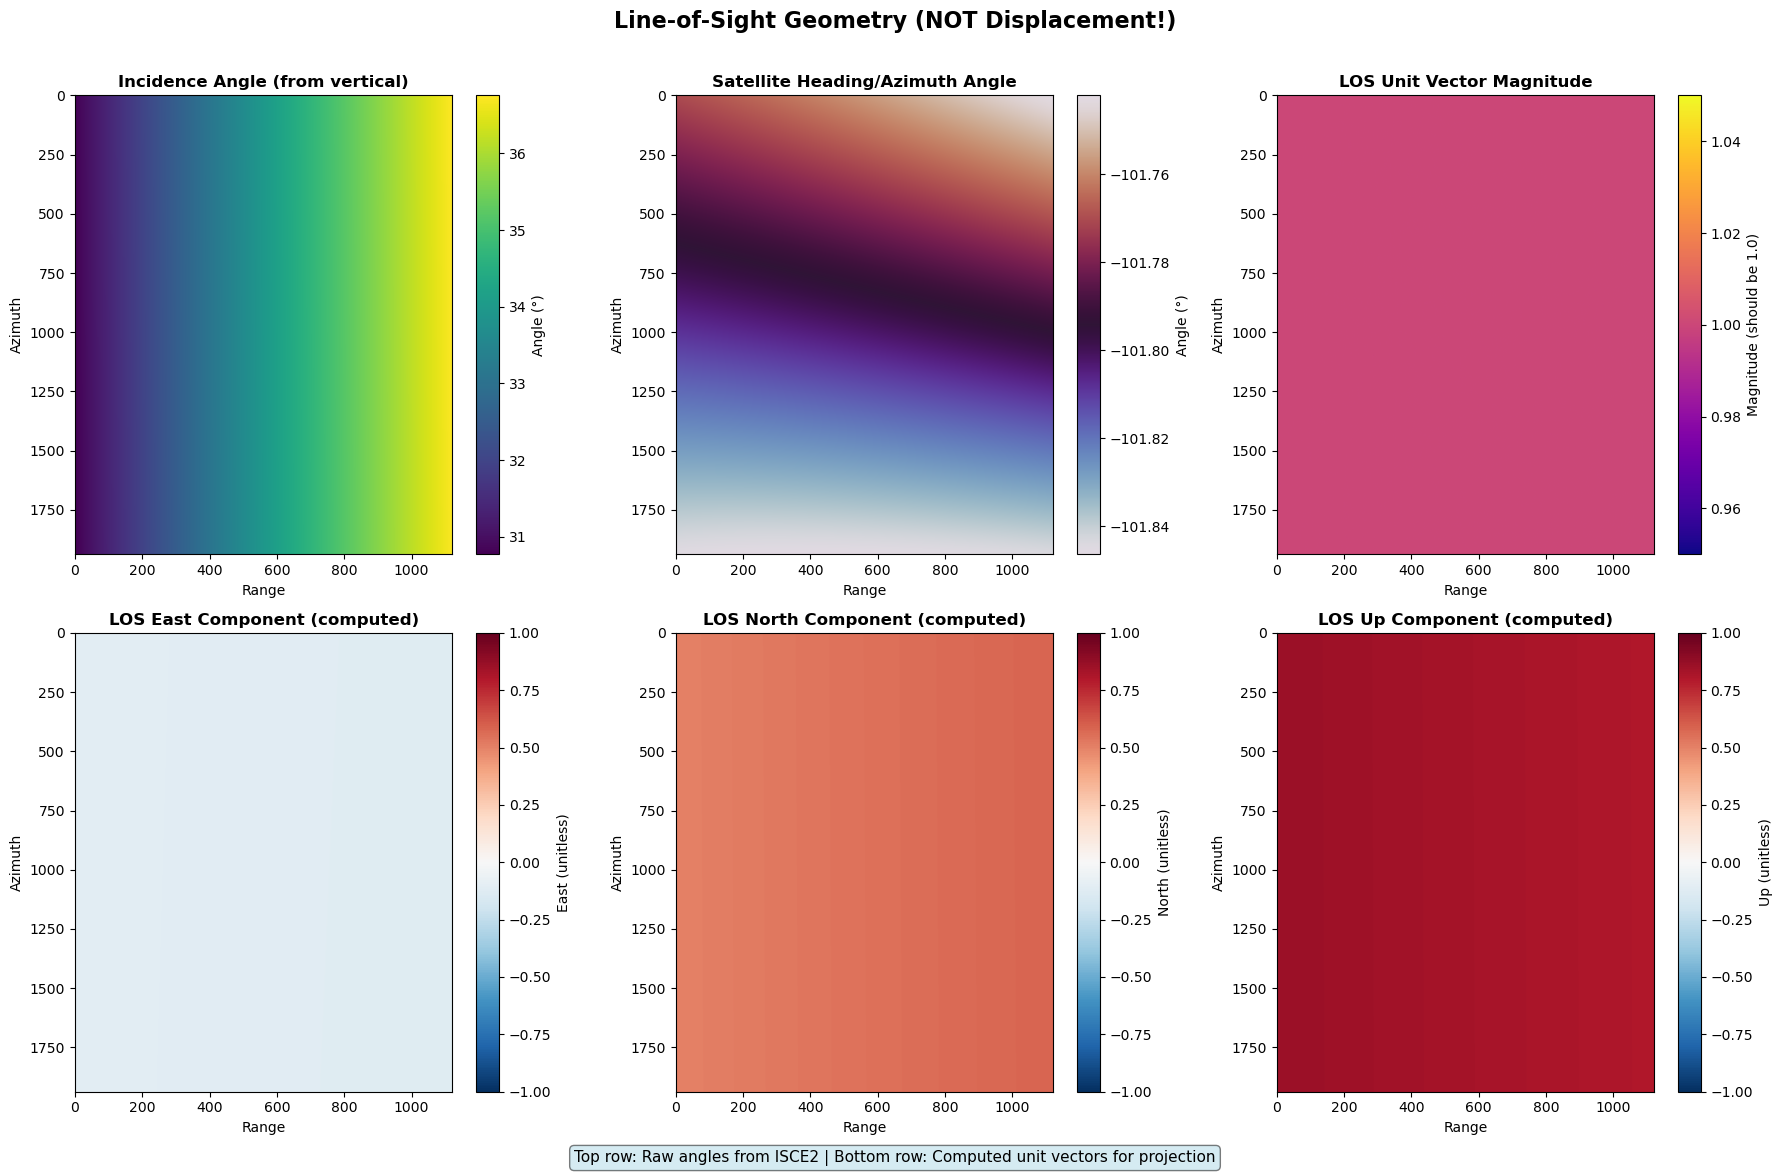

✅ LOS geometry plot saved as 'los_geometry.png'


In [24]:
# Plot LOS geometry
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Incidence angle (raw)
im1 = axes[0, 0].imshow(incidence_angle, cmap='viridis', aspect='auto')
axes[0, 0].set_title('Incidence Angle (from vertical)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Range')
axes[0, 0].set_ylabel('Azimuth')
plt.colorbar(im1, ax=axes[0, 0], label='Angle (°)')

# Heading angle (raw)
im2 = axes[0, 1].imshow(heading_angle, cmap='twilight', aspect='auto')
axes[0, 1].set_title('Satellite Heading/Azimuth Angle', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Range')
axes[0, 1].set_ylabel('Azimuth')
plt.colorbar(im2, ax=axes[0, 1], label='Angle (°)')

# LOS vector magnitude (should be ~1)
los_magnitude = np.sqrt(los_east**2 + los_north**2 + los_up**2)
im3 = axes[0, 2].imshow(los_magnitude, cmap='plasma', vmin=0.95, vmax=1.05, aspect='auto')
axes[0, 2].set_title('LOS Unit Vector Magnitude', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Range')
axes[0, 2].set_ylabel('Azimuth')
plt.colorbar(im3, ax=axes[0, 2], label='Magnitude (should be 1.0)')

# East component (computed)
im4 = axes[1, 0].imshow(los_east, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1, 0].set_title('LOS East Component (computed)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Range')
axes[1, 0].set_ylabel('Azimuth')
plt.colorbar(im4, ax=axes[1, 0], label='East (unitless)')

# North component (computed)
im5 = axes[1, 1].imshow(los_north, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1, 1].set_title('LOS North Component (computed)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Range')
axes[1, 1].set_ylabel('Azimuth')
plt.colorbar(im5, ax=axes[1, 1], label='North (unitless)')

# Up component (computed)
im6 = axes[1, 2].imshow(los_up, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1, 2].set_title('LOS Up Component (computed)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Range')
axes[1, 2].set_ylabel('Azimuth')
plt.colorbar(im6, ax=axes[1, 2], label='Up (unitless)')

fig.suptitle('Line-of-Sight Geometry (NOT Displacement!)', fontsize=16, fontweight='bold')
fig.text(0.5, 0.02, 'Top row: Raw angles from ISCE2 | Bottom row: Computed unit vectors for projection', 
         ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('los_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ LOS geometry plot saved as 'los_geometry.png'") 

## 5. Phase Histogram Analysis

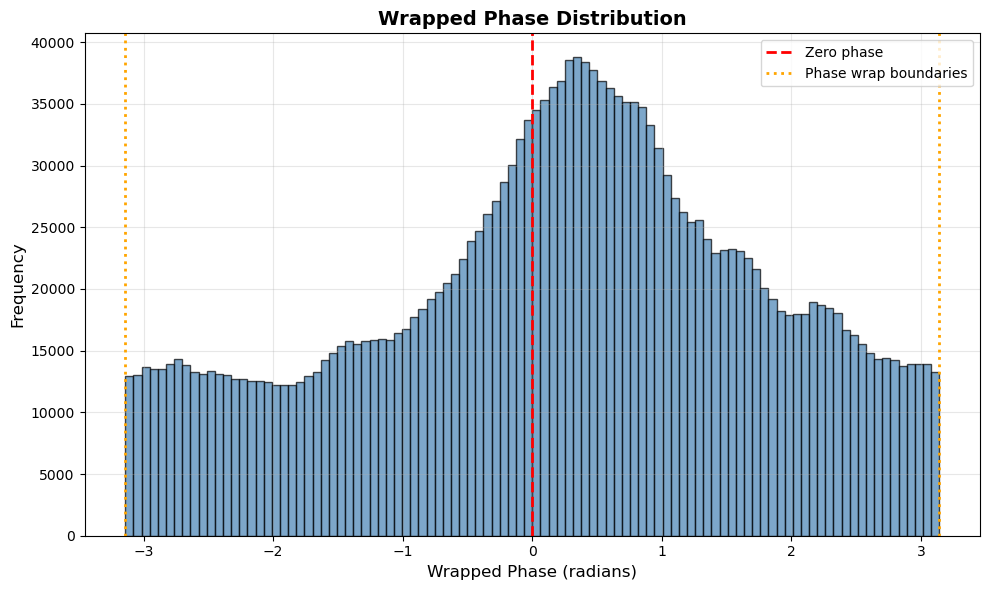

✅ Phase histogram saved as 'phase_histogram.png'


In [25]:
# Plot phase histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

phase_flat = phase_wrapped[~np.isnan(phase_wrapped)]
ax.hist(phase_flat, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Wrapped Phase (radians)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Wrapped Phase Distribution', fontsize=14, fontweight='bold')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero phase')
ax.axvline(-np.pi, color='orange', linestyle=':', linewidth=2, label='Phase wrap boundaries')
ax.axvline(np.pi, color='orange', linestyle=':', linewidth=2)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('phase_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Phase histogram saved as 'phase_histogram.png'")

## 6. Generate Summary Report

In [ ]:
# Summary statistics
print("="*70)
print("InSAR PROCESSING SUMMARY")
print("="*70)
print(f"\nData Information:")
print(f"  Reference date: 2021-01-31")
print(f"  Secondary date: 2021-02-12")
print(f"  Temporal baseline: 12 days")
print(f"  Location: Area near Tokyo, Japan (actual coverage below)")
print(f"  Sensor: Sentinel-1A")
print(f"  Mode: IW-1 (Interferometric Wide swath, subswath 1)")
print(f"  Wavelength: 5.6 cm (C-band)")

print(f"\nImage Dimensions:")
print(f"  Radar coordinates: {amplitude.shape[0]} x {amplitude.shape[1]} pixels")
print(f"  Geocoded: {amplitude_geo.shape[0]} x {amplitude_geo.shape[1]} pixels")

print(f"\nQuality Metrics:")
print(f"  Mean coherence: {np.nanmean(coherence):.3f} (from phsig.cor)")
print(f"  High coherence pixels (>0.7): {(np.sum(coherence > 0.7) / np.sum(~np.isnan(coherence)) * 100):.1f}%")
print(f"  Good coherence pixels (0.5-0.7): {(np.sum((coherence > 0.5) & (coherence <= 0.7)) / np.sum(~np.isnan(coherence)) * 100):.1f}%")
print(f"  Low coherence pixels (<0.5): {(np.sum(coherence < 0.5) / np.sum(~np.isnan(coherence)) * 100):.1f}%")

print(f"\nAmplitude Statistics:")
print(f"  Raw amplitude range: {np.nanmin(amplitude):.1f} to {np.nanmax(amplitude):.1f}")
print(f"  Mean amplitude: {np.nanmean(amplitude):.1f}")
print(f"  Note: Log scale used for visualization due to huge dynamic range")

print(f"\nPhase Statistics (WRAPPED):")
print(f"  ⚠️  Phase is WRAPPED between -π and π")
print(f"  Phase range: {np.nanmin(phase_wrapped):.3f} to {np.nanmax(phase_wrapped):.3f} radians")
print(f"  Phase mean: {np.nanmean(phase_wrapped):.3f} radians")
print(f"  Phase std: {np.nanstd(phase_wrapped):.3f} radians")
print(f"  Each 2π cycle = ~2.8 cm LOS displacement (Sentinel-1 C-band)")

print(f"\nGeographic Coverage:")
print(f"  Longitude: {lon_origin:.4f}° to {lon_max:.4f}° ({abs(lon_max - lon_origin):.4f}° width)")
print(f"  Latitude: {lat_min:.4f}° to {lat_origin:.4f}° ({abs(lat_origin - lat_min):.4f}° height)")
print(f"  Pixel spacing: {pixel_width:.6f}° x {abs(pixel_height):.6f}°")
print(f"  Approximate spacing: {pixel_width*111:.1f} m x {abs(pixel_height)*111:.1f} m")

print(f"\nLOS Geometry:")
print(f"  Mean incidence angle: {np.nanmean(incidence_angle):.2f}°")
print(f"  Incidence angle range: {np.nanmin(incidence_angle):.2f}° to {np.nanmax(incidence_angle):.2f}°")
print(f"  Mean heading angle: {np.nanmean(heading_angle):.2f}°")
print(f"  LOS unit vector magnitude: {np.nanmean(np.sqrt(los_east**2 + los_north**2 + los_up**2)):.3f} (should be ~1.0)")

print(f"\n{'='*70}")
print("WHAT'S AVAILABLE vs NOT AVAILABLE")
print(f"{'='*70}")
print("\n✅ VISUALIZED IN THIS NOTEBOOK:")
print("   - Wrapped interferometric phase (-π to π)")
print("   - Amplitude (backscatter intensity) with log₁₀ scaling")
print("   - Coherence (normalized to 0-1 range)")
print("   - LOS geometry: incidence & heading angles + computed E/N/U vectors")

print("\n❌ NOT AVAILABLE (phase unwrapping was disabled):")
print("   - Unwrapped phase")
print("   - Line-of-sight displacement")
print("   - Actual deformation measurements in cm/mm")

print("\n📊 DATA QUALITY NOTES:")
print("   - Amplitude has huge dynamic range (1-1.5M), requiring log scale")
print("   - Used phsig.cor (actual coherence) not topophase.cor (raw correlation)")
print("   - LOS file contains angles, not unit vectors (we computed E/N/U)")

print("\n💡 TO GET DISPLACEMENT:")
print("   1. Edit input-files/topsApp.xml")
print("   2. Uncomment these lines:")
print('      <property name="do unwrap">True</property>')
print('      <property name="unwrapper name">snaphu_mcf</property>')
print("   3. Re-run: docker compose run --rm isce2-insar topsApp.py input-files/topsApp.xml")
print("   4. Output will include unwrapped phase files (.unw)")

print("\n" + "="*70)
print("Output Files Generated:")
print("="*70)
print("  ✅ interferogram_radar_coords.png - Phase & amplitude (log scale)")
print("  ✅ coherence_map.png - Normalized quality assessment")
print("  ✅ interferogram_geocoded.png - Geocoded phase & amplitude (log)")
print("  ✅ los_geometry.png - 6-panel: angles + computed E/N/U vectors")
print("  ✅ phase_histogram.png - Phase distribution")
print("="*70)

InSAR PROCESSING SUMMARY

Data Information:
  Reference date: 2021-01-31
  Secondary date: 2021-02-12
  Temporal baseline: 12 days
  Location: Area near Tokyo, Japan (actual coverage below)
  Sensor: Sentinel-1A
  Mode: IW-1 (Interferometric Wide swath, subswath 1)
  Wavelength: 5.6 cm (C-band)

Image Dimensions:
  Radar coordinates: 1938 x 1122 pixels
  Geocoded: 6755 x 4491 pixels

Quality Metrics:
  Mean coherence: 0.172 (normalized)
  High coherence pixels (>0.7): 0.0%
  Good coherence pixels (0.5-0.7): 0.0%
  Low coherence pixels (<0.5): 100.0%

Amplitude Statistics:
  Raw amplitude range: 1.3 to 1519865.0
  Mean amplitude: 3108.3
  Note: Log scale used for visualization due to huge dynamic range

Phase Statistics (WRAPPED):
  ⚠️  Phase is WRAPPED between -π and π
  Phase range: -3.142 to 3.142 radians
  Phase mean: 0.206 radians
  Phase std: 1.556 radians
  Each 2π cycle = ~2.8 cm LOS displacement (Sentinel-1 C-band)

Geographic Coverage:
  Longitude: -60.3294° to -59.0819° (1.24